# Imports

In [1]:
%pip install -q --upgrade --force-reinstall "protobuf>=6.31.1,<7"
%pip install -q --upgrade --force-reinstall tensorflow-datasets
%pip install -q --upgrade numpy scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 81.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 13.6 MB/s eta 0:00:00
 

In [1]:
import io
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # type: ignore
import tensorflow_datasets as tfds # type: ignore
import tensorflow_probability as tfp # type: ignore
import sklearn 
import datetime
from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import cv2
import albumentations as A # type: ignore
import wandb
import kagglehub # type: ignore

# MODELS
Model = tf.keras.Model

#LAYERS
Layer = tf.keras.layers.Layer # importing Layer Class to inherit from
Input = tf.keras.layers.Input
Normalization = tf.keras.layers.Normalization
Dense = tf.keras.layers.Dense
InputLayer = tf.keras.layers.InputLayer
Conv2D = tf.keras.layers.Conv2D
MaxPool2D = tf.keras.layers.MaxPool2D
Flatten = tf.keras.layers.Flatten # Flatten is a function so you don't need a parantheses at the end.
BatchNormalization = tf.keras.layers.BatchNormalization
Dropout =  tf.keras.layers.Dropout
RandomRotation = tf.keras.layers.RandomRotation
RandomFlip = tf.keras.layers.RandomFlip
Resizing = tf.keras.layers.Resizing
Rescaling = tf.keras.layers.Rescaling

#LOSSES
bce = tf.keras.losses.BinaryCrossentropy() # To instantiate a class you need to build an object which can only be done by including a parantheses at the end. 

# OPTIMIZER
Adam = tf.keras.optimizers.Adam

# METRICS
BinaryAccuracy = tf.keras.metrics.BinaryAccuracy # For a Binary Classification Problem
FalsePositives = tf.keras.metrics.FalsePositives
FalseNegatives = tf.keras.metrics.FalseNegatives
TruePositives = tf.keras.metrics.TruePositives
TrueNegatives = tf.keras.metrics.TrueNegatives
Precision = tf.keras.metrics.Precision
Recall = tf.keras.metrics.Recall
AUC = tf.keras.metrics.AUC
binary_accuracy = tf.keras.metrics.binary_accuracy
CategoricalAccuracy = tf.keras.metrics.CategoricalAccuracy
TopKCategoricalAccuracy = tf.keras.metrics.TopKCategoricalAccuracy

# Callbacks
Callback = tf.keras.callbacks.Callback
CSVLogger = tf.keras.callbacks.CSVLogger
LearningRateScheduler = tf.keras.callbacks.LearningRateScheduler
ProgBarLogger = tf.keras.callbacks.ProgbarLogger
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint
ReduceLRonPlateau = tf.keras.callbacks.ReduceLROnPlateau

# Regularizer
L2 = tf.keras.regularizers.L2

# Distributions
Beta = tfp.distributions.Beta

# Hyperparameter Tuning
from tensorboard.plugins.hparams import api as hp
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint, WandbEvalCallback # type: ignore

from pathlib import Path
import imghdr

/tmp/ipykernel_1089/1555399488.py:74: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


# Data Management

## Data Downloading

In [2]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown




In [3]:
!unzip -q "/content/human-emotions-datasethes.zip" -d "/content/dataset/"

In [4]:
TRAIN_DIRECTORY = '/content/dataset/Emotions Dataset/Emotions Dataset/train'
VALIDATION_DIRECTORY = '/content/dataset/Emotions Dataset/Emotions Dataset/test'

In [16]:
CONFIGURATION = {
    "BATCH_SIZE": 32,
    "IM_SIZE": 256,
    "LEARNING_RATE": 1e-3,
    "N_EPOCHS": 5,
    "DROPOUT_RATE": 0.0,
    "REGULARIZATION_RATE": 0.0,
    "N_FILTERS": 6,
    "KERNEL_SIZE": 3,
    "N_STRIDES": 1,
    "POOL_SIZE": 2,
    "N_DENSE_1": 1024,
    "N_DENSE_2": 128,
    "NUM_CLASSES": 3,
    "PATCH_SIZE": 16,
    "PROJ_DIM": 768,
    "CLASS_NAMES": ["angry", "happy", "sad"],
}
 

In [6]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIRECTORY,
    labels='inferred',
    label_mode='categorical',
    class_names=CONFIGURATION['CLASS_NAMES'],
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=99)

Found 6799 files belonging to 3 classes.


In [7]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    VALIDATION_DIRECTORY,
    labels='inferred',
    label_mode='categorical',
    class_names=CONFIGURATION['CLASS_NAMES'],
    color_mode='rgb',
    batch_size=CONFIGURATION['BATCH_SIZE'],
    image_size=(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']),
    shuffle=True,
    seed=99)

Found 2278 files belonging to 3 classes.


In [8]:
for i in val_dataset.take(1): # taking one batch
    print(i)

(<tf.Tensor: shape=(32, 256, 256, 3), dtype=float32, numpy=
array([[[[ 20.        ,  20.        ,  20.        ],
         [ 19.1875    ,  19.1875    ,  19.1875    ],
         [ 19.        ,  19.        ,  19.        ],
         ...,
         [ 29.125     ,  29.125     ,  29.125     ],
         [ 25.        ,  25.        ,  25.        ],
         [ 25.        ,  25.        ,  25.        ]],

        [[ 20.        ,  20.        ,  20.        ],
         [ 19.847656  ,  19.847656  ,  19.847656  ],
         [ 19.8125    ,  19.8125    ,  19.8125    ],
         ...,
         [ 28.820312  ,  28.820312  ,  28.820312  ],
         [ 25.660156  ,  25.660156  ,  25.660156  ],
         [ 25.        ,  25.        ,  25.        ]],

        [[ 20.6875    ,  20.6875    ,  20.6875    ],
         [ 21.246094  ,  21.246094  ,  21.246094  ],
         [ 21.847656  ,  21.847656  ,  21.847656  ],
         ...,
         [ 25.3125    ,  25.3125    ,  25.3125    ],
         [ 22.375     ,  22.375     ,  22.375 

# Data Visualization

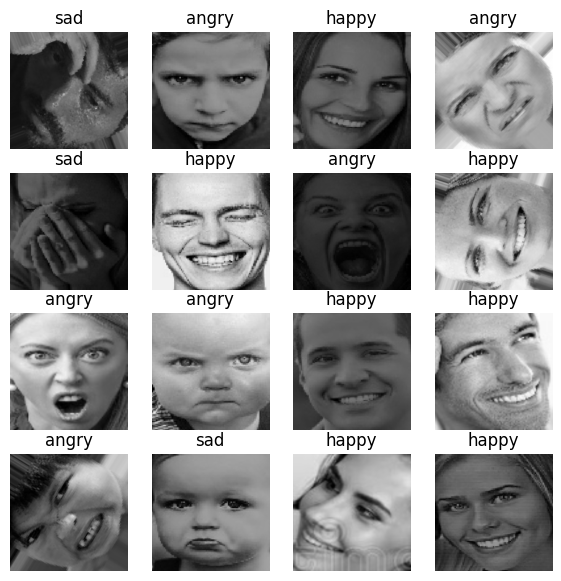

In [10]:
plt.figure(figsize = (7,7))
for images, labels in train_dataset.take(1):
    for i in range(16):
        ax = plt.subplot(4,4,i+1)
        plt.imshow(images[i]/255)
        plt.title(CONFIGURATION['CLASS_NAMES'][tf.argmax(labels[i], axis = 0).numpy()])
        plt.axis('off')

# Dataset Preparation

In [9]:
training_datset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

In [10]:
# These will be the layers in the MODEL
resize_rescale_layers = tf.keras.Sequential([
    Resizing(CONFIGURATION['IM_SIZE'], CONFIGURATION['IM_SIZE']), 
    Rescaling(1./255),])

# Data Augmentation

# Modeling

In [11]:
lenet_model = tf.keras.Sequential([
    InputLayer(shape = (None, None, 3), ), # designed to accept images of any height and any width

    resize_rescale_layers,
    
    Conv2D(filters = CONFIGURATION["N_FILTERS"] , kernel_size = CONFIGURATION["KERNEL_SIZE"], strides = CONFIGURATION["N_STRIDES"] , padding='valid',
          activation = 'relu',kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"] ),

    Conv2D(filters = CONFIGURATION["N_FILTERS"]*2 + 4, kernel_size = CONFIGURATION["KERNEL_SIZE"], strides=CONFIGURATION["N_STRIDES"], padding='valid',
          activation = 'relu', kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    MaxPool2D (pool_size = CONFIGURATION["POOL_SIZE"], strides= CONFIGURATION["N_STRIDES"]*2),

    Flatten(),
    
    Dense( CONFIGURATION["N_DENSE_1"], activation = "relu", kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),
    Dropout(rate = CONFIGURATION["DROPOUT_RATE"]),
    
    Dense( CONFIGURATION['N_DENSE_2'], activation = "relu", kernel_regularizer = L2(CONFIGURATION["REGULARIZATION_RATE"])),
    BatchNormalization(),

    Dense(CONFIGURATION["NUM_CLASSES"], activation = "softmax"),
])
lenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    62,981,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,118,451 (240.78 MB)

 Trainable params: 63,116,103 (240.77 MB)

 Non-trainable params: 2,348 (9.17 KB)

# Training

In [13]:
loss_function = tf.keras.losses.CategoricalCrossentropy()
# loss_function = tf.keras.losses.SparseCategoricalCrossentropy() to use when label_mode='int'
# from_logits = True if the last layer didn't have a 'softmax' activation function
metrics = [CategoricalAccuracy(name = 'accuracy'), TopKCategoricalAccuracy(k=2, name='Top_k_Accuracy') ]

In [14]:
lenet_model.compile(optimizer= Adam(learning_rate = CONFIGURATION['LEARNING_RATE']),
                    loss = loss_function,
                    metrics = metrics)

In [17]:
History = lenet_model.fit(train_dataset,
                        validation_data=validation_dataset,
                        epochs=CONFIGURATION['N_EPOCHS'],
                        verbose=1) 

Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - Top_k_Accuracy: 0.8506 - accuracy: 0.5951 - loss: 0.9003 - val_Top_k_Accuracy: 0.7783 - val_accuracy: 0.3771 - val_loss: 1.1473
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - Top_k_Accuracy: 0.9297 - accuracy: 0.7604 - loss: 0.5876 - val_Top_k_Accuracy: 0.6809 - val_accuracy: 0.4034 - val_loss: 1.4355
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - Top_k_Accuracy: 0.9662 - accuracy: 0.8570 - loss: 0.3729 - val_Top_k_Accuracy: 0.7322 - val_accuracy: 0.4271 - val_loss: 1.5505
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - Top_k_Accuracy: 0.9819 - accuracy: 0.9097 - loss: 0.2580 - val_Top_k_Accuracy: 0.8385 - val_accuracy: 0.5461 - val_loss: 1.4245
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - Top_k_Accuracy: 0.9874 - accuracy: 0.9313 - loss: 0.1966 - val_Top_k_Accuracy: 0.8433 - val_accuracy: 0.6040 - val_loss: 1.3089


<class 'keras.src.callbacks.history.History'>
dict_keys(['Top_k_Accuracy', 'accuracy', 'loss', 'val_Top_k_Accuracy', 'val_accuracy', 'val_loss'])


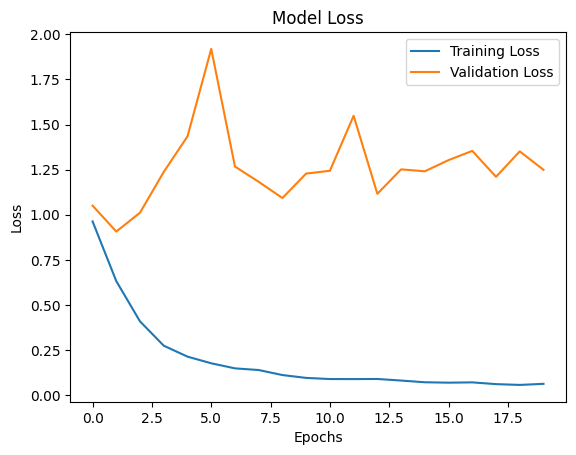

In [18]:
print(type(History))
print(History.history.keys())
plt.plot(History.history['loss'], label='Training Loss') 
plt.plot(History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

<class 'keras.src.callbacks.history.History'>
dict_keys(['Top_k_Accuracy', 'accuracy', 'loss', 'val_Top_k_Accuracy', 'val_accuracy', 'val_loss'])


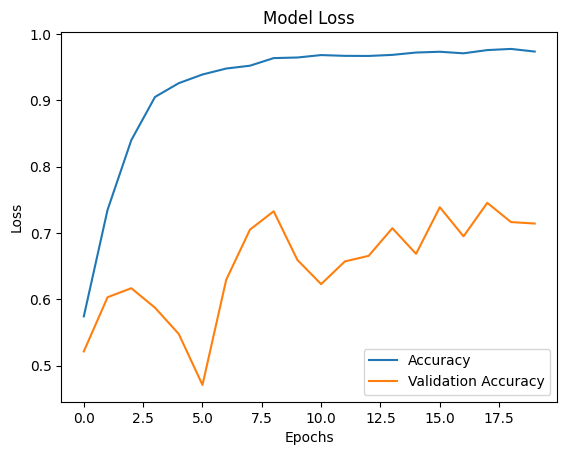

In [20]:
print(type(History))
print(History.history.keys())
plt.plot(History.history['accuracy'], label='Accuracy') 
plt.plot(History.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

# Evaluation

In [19]:
lenet_model.evaluate(validation_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - Top_k_Accuracy: 0.8911 - accuracy: 0.7142 - loss: 1.2491


[1.249074101448059, 0.7142230272293091, 0.8911325931549072]

# Testing

sad


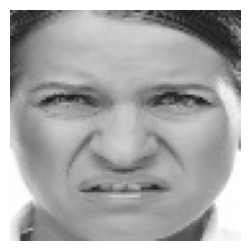

In [28]:
test_image = cv2.imread('/content/dataset/Emotions Dataset/Emotions Dataset/test/sad/123731.jpg')
im = tf.constant(test_image, dtype=tf.float32) # convert to a tensor
im = tf.expand_dims(im, axis = 0)
plt.figure(figsize = (3,3))
plt.imshow(test_image)
plt.axis('off')
print(CONFIGURATION['CLASS_NAMES'][tf.argmax(lenet_model(im), axis = 1).numpy()[0]])


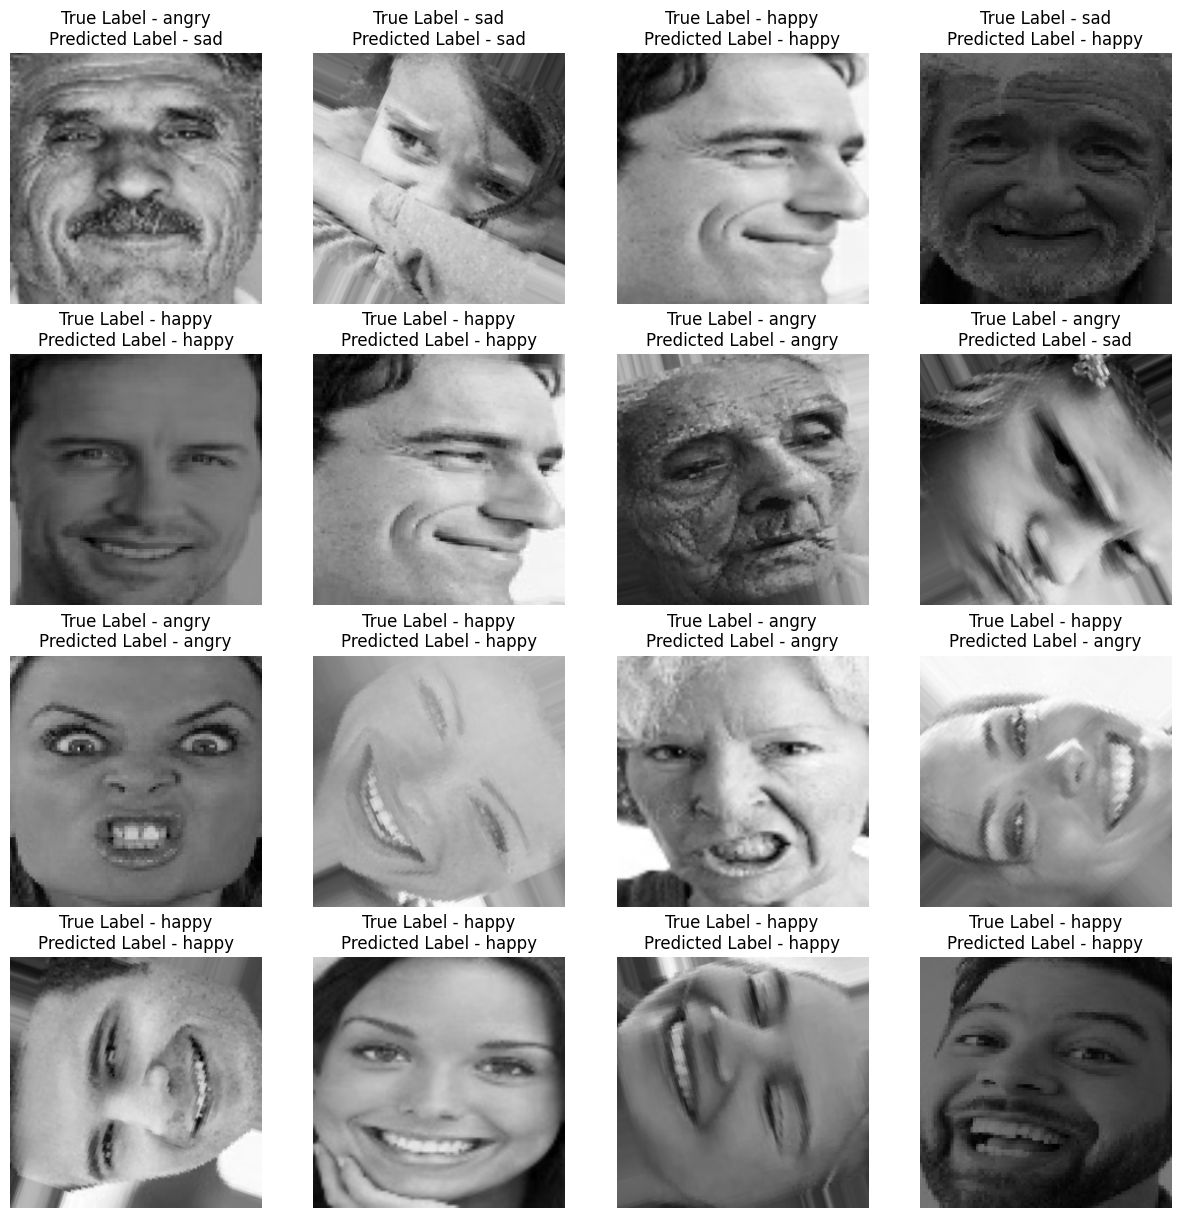

In [34]:
plt.figure(figsize = (15,15))
for images, labels in validation_dataset.take(1):
    for i in range(16):
        ax = plt.subplot(4,4,i+1)
        plt.imshow(images[i]/255)
        plt.title('True Label - ' + CONFIGURATION['CLASS_NAMES'][tf.argmax(labels[i], axis = 0).numpy()]
                + '\n' + 'Predicted Label - ' + CONFIGURATION['CLASS_NAMES'][tf.argmax(lenet_model(tf.expand_dims(images[i], axis = 0)), axis =-1).numpy()[0]])
        plt.axis('off')

# Confusion Matrix

In [49]:
predicted = []
labels = []

for im, label in validation_dataset:
    predicted.append(lenet_model(im))
    labels.append(label.numpy())

In [55]:
print(np.concatenate([np.argmax(labels[:-1], axis = -1).flatten(), np.argmax(labels[-1], axis = -1).flatten()])) # class names of all batches into a 1 dimension list + all batches of 32 + the last batch
print(np.concatenate([np.argmax(predicted[:-1], axis = -1).flatten(), np.argmax(predicted[-1], axis = -1).flatten()]))

[0 1 1 ... 2 2 0]
[0 1 1 ... 2 2 0]


In [56]:
pred = np.concatenate([np.argmax(labels[:-1], axis = -1).flatten(), np.argmax(labels[-1], axis = -1).flatten()])
lab = np.concatenate([np.argmax(predicted[:-1], axis = -1).flatten(), np.argmax(predicted[-1], axis = -1).flatten()])

[[332  76  91]
 [ 85 804 155]
 [ 98 126 511]]


Text(0.5, 36.72222222222221, 'Predicted')

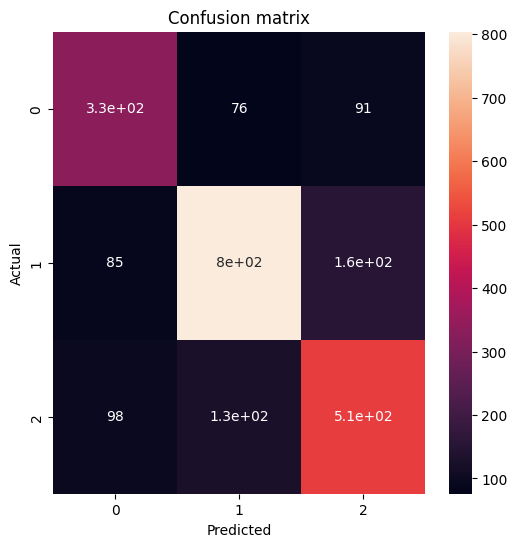

In [57]:
cm = confusion_matrix(lab, pred) 
print(cm)
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True,)
plt.title(f'Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')